In [1]:
import sys
sys.path.append("..")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from DicomToNumpyClass import DicomToNumpy
from preprocessor.preprocessor import CTManager
from brain_extraction.brain_extractor import BrainExtractorManager
from kernel_extraction.kernel_extractor import KernelExtractorManager
processor = DicomToNumpy("../Brain_Stroke_CT_Dataset")
subdataset = processor.get_subset(limit = 1000) # tomo solo las 1000 primeras imágenes
subdataset_filtered = CTManager.process_batch_clean_image(subdataset)
subdataset_filtered = BrainExtractorManager(subdataset_filtered).extract_all_brains(plot_examples=False)
kernel_manager = KernelExtractorManager(subdataset_filtered, patch_size=32)
kernels_dataset = kernel_manager.extract_all(patches_per_lesion=3)

## Función para visualizar Boxplot de Features
Definición de plot_feature_distributions(df_features) para observar si la feature es significativa frente a las demás clases.

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

def plot_feature_distributions(df):
    """
    Genera una grilla de boxplots para cada característica numérica en el DataFrame,
    separada y coloreada por clase (Normal, Bleeding, Ischemia).
    """
    print("Generando gráficos estadísticos...")
    
    # Extraemos todas las columnas que son características (ignoramos 'label')
    features = [col for col in df.columns if col != 'label']
    num_features = len(features)
    
    # Configuramos una grilla de 3 columnas y las filas necesarias
    cols = 3
    rows = math.ceil(num_features / cols)
    
    # Creamos la figura general
    fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
    axes = axes.flatten() # Aplanamos el array de ejes para iterar fácil
    
    # Definimos colores fijos para no confundirnos visualmente
    palette_colors = {'Normal': '#2ca02c',     # Verde
                      'Bleeding': '#d62728',   # Rojo
                      'Ischemia': '#1f77b4'}   # Azul
    
    for i, feature in enumerate(features):
        # Ploteamos el boxplot
        sns.boxplot(
            data=df, 
            x='label', 
            y=feature, 
            ax=axes[i], 
            palette=palette_colors,
            hue='label', # Asignar el hue a la misma variable X evita warnings de seaborn
            legend=False
        )
        
        # Títulos y limpieza de ejes
        axes[i].set_title(f"Distribución: {feature}", fontsize=12, fontweight='bold')
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Valor")
        axes[i].grid(True, axis='y', alpha=0.3)
        
    # Si la grilla tiene huecos vacíos al final (ej. 14 features en 15 espacios), los borramos
    for j in range(num_features, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

# --- EJEMPLO DE USO ---
# Simplemente llámalo pasándole tu DataFrame recién creado:
# plot_feature_distributions(df_features)

## Feature Extractor
Obtengo Kernels de 32x32 de cada tejido:
- Normal: proviene de 'brain' (tejido sano).
- Ischemia/Bleeding: proviene de 'overlay' (tejido no sano).

In [8]:
from feature_extraction.feature_extract import FeatureExtractManager

In [9]:
feature_manager = FeatureExtractManager(kernels_dataset)
df_features = feature_manager.extract_all_to_dataframe()

Iniciando extracción radiómica (First-Order, GLCM, LDOP-Gradients)...
  -> Minando características para clase: Bleeding (2884 parches)
  -> Minando características para clase: Ischemia (2884 parches)
  -> Minando características para clase: Normal (2884 parches)
--------------------------------------------------
EXTRACCIÓN COMPLETADA.
Dataset estructurado final: 8652 filas (ejemplos) x 15 columnas (features + label)
--------------------------------------------------


Generando gráficos estadísticos...


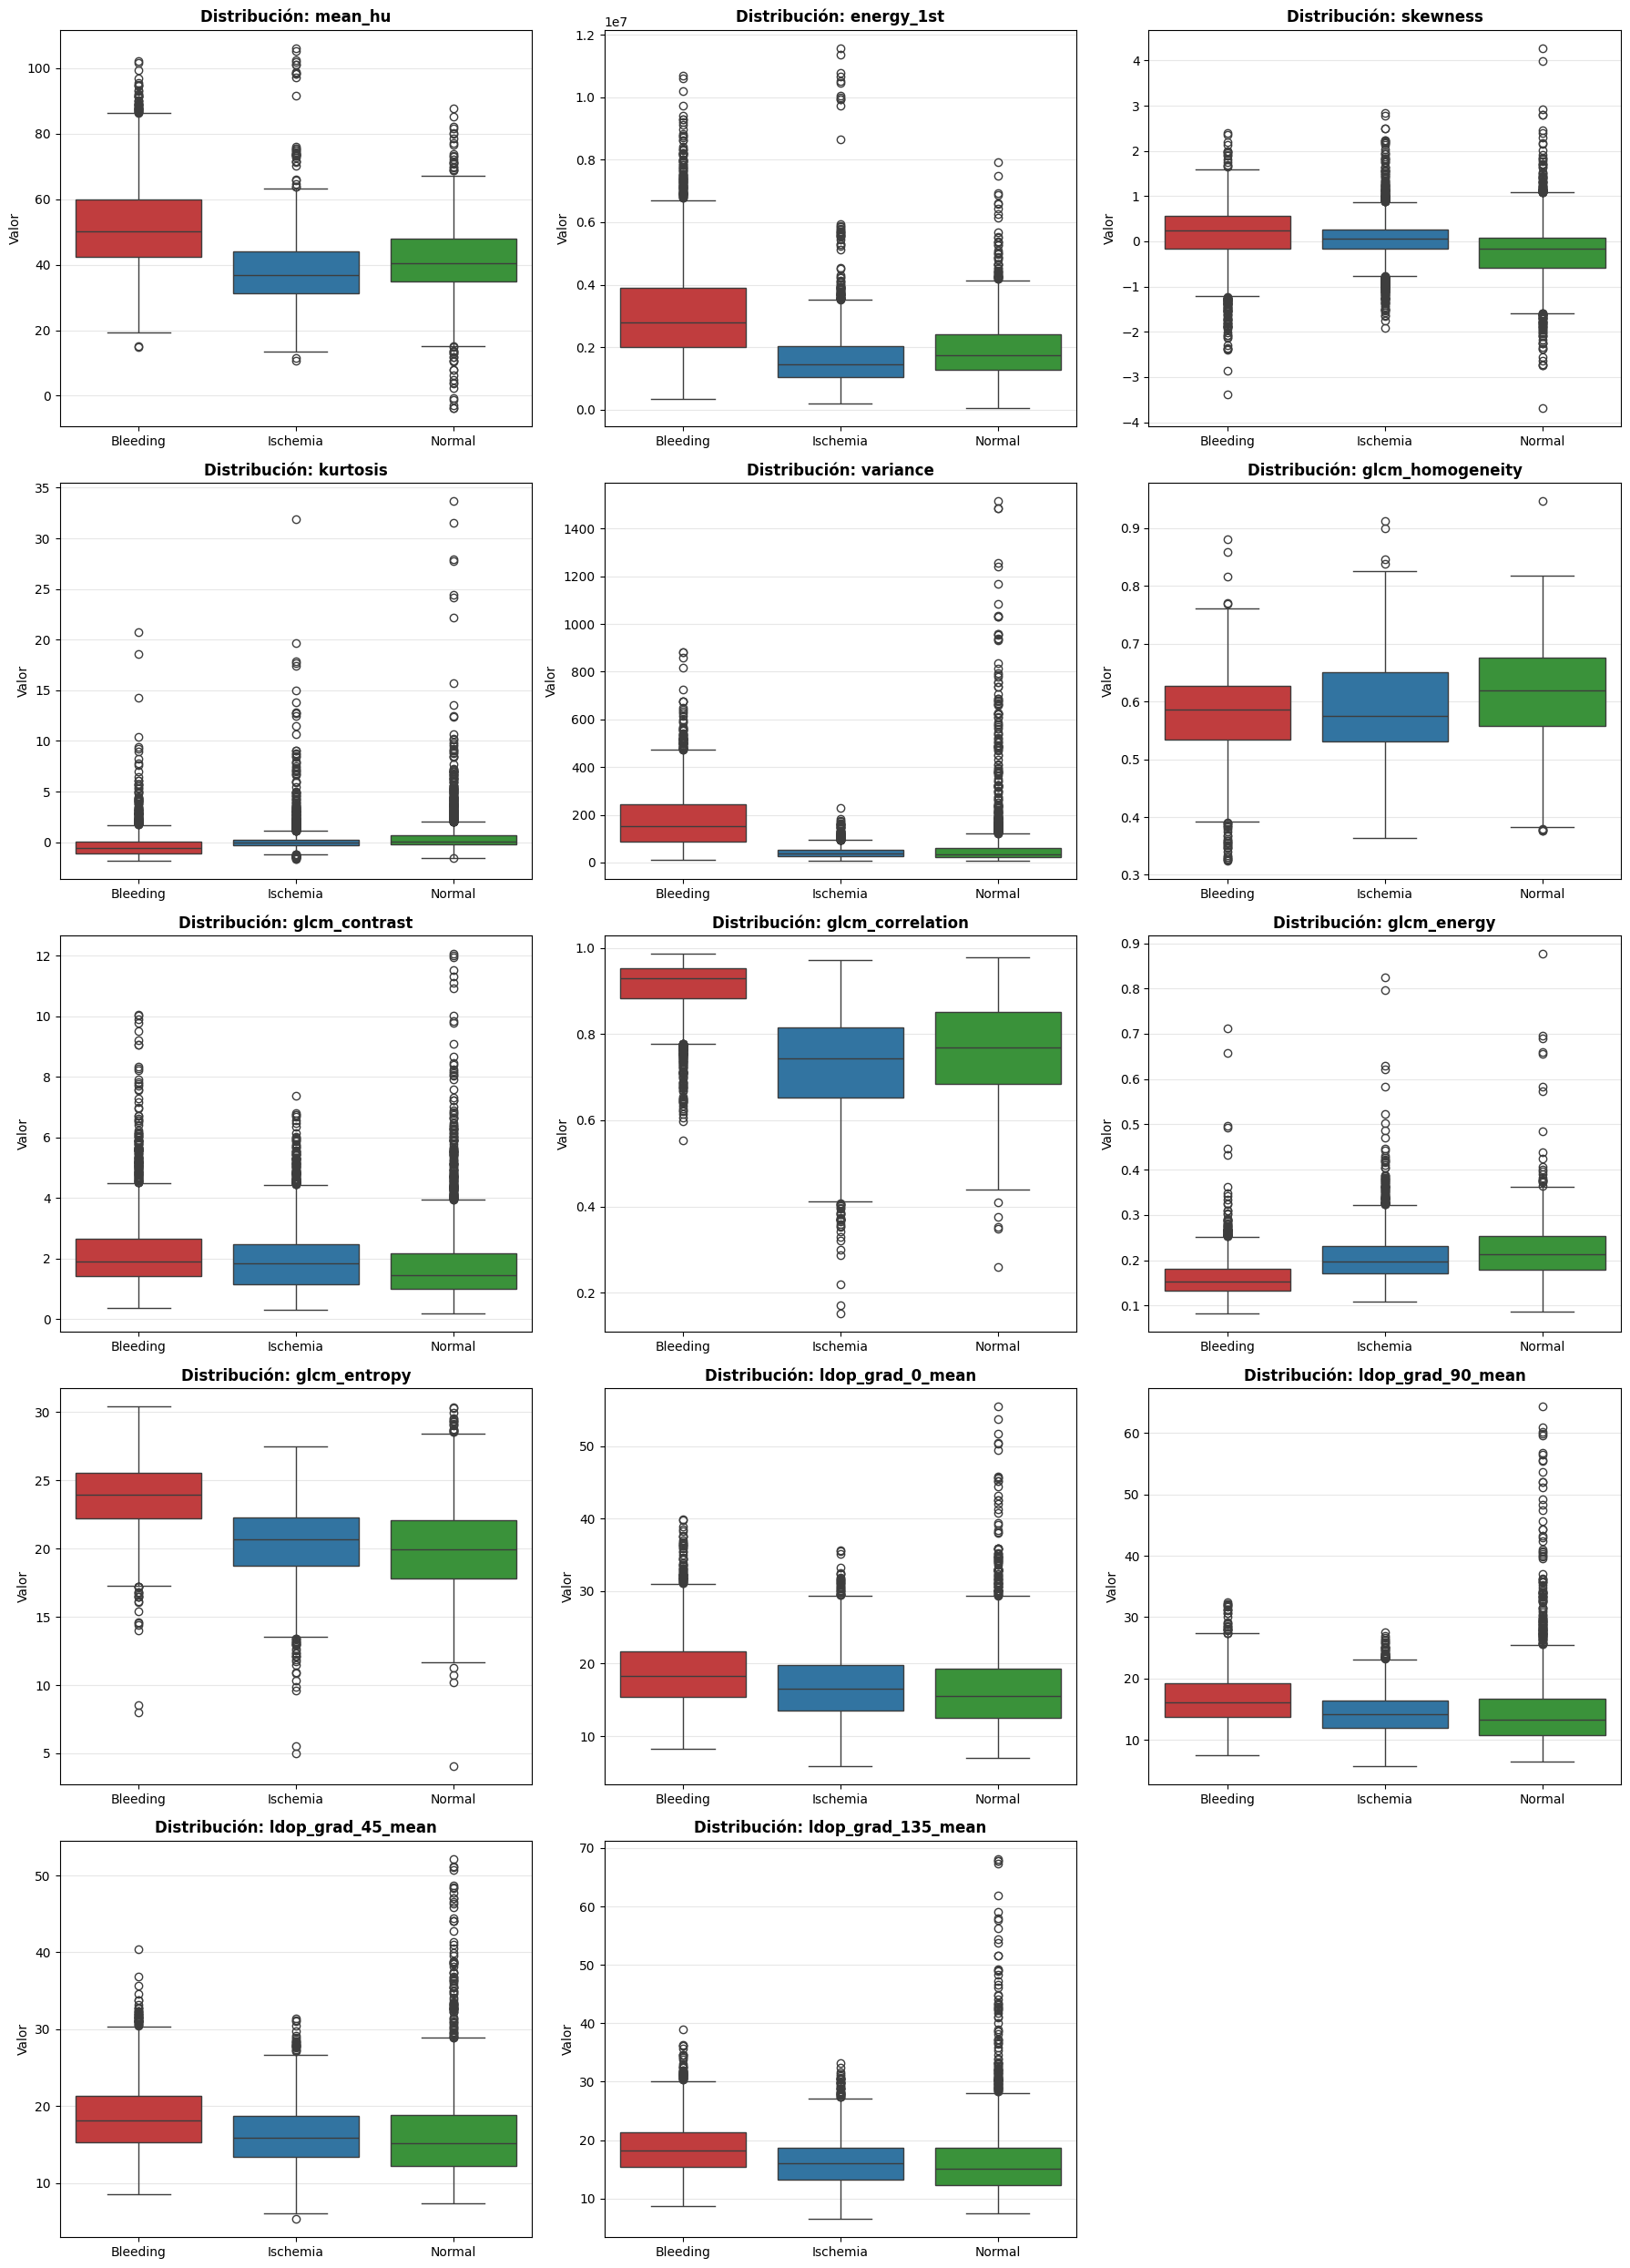

In [11]:
plot_feature_distributions(df_features)

# Almacenamiento del Kernel
Para no volver a correr los códigos para general los kernels (que lleva su tiempo) lo almaceno como NumPy.

#### Función

In [ ]:
import os
import numpy as np
from pathlib import Path

def save_kernels_dataset(kernels_dict, output_folder="../Kernels_datasets_numpy"):
    """
    Guarda el diccionario de kernels en la carpeta especificada, 
    creando archivos secuenciales (kernel_dataset_1.npy, kernel_dataset_2.npy, etc.)
    """
    folder_path = Path(output_folder)
    # Crea la carpeta si no existe
    folder_path.mkdir(parents=True, exist_ok=True)
    
    # Buscamos todos los archivos que coincidan con el patrón
    existing_files = list(folder_path.glob("kernel_dataset_*.npy"))
    
    max_num = 0
    for f in existing_files:
        try:
            # Extraemos el número del nombre del archivo
            # Ej: de "kernel_dataset_3.npy" sacamos el "3"
            num = int(f.stem.split('_')[-1])
            if num > max_num:
                max_num = num
        except ValueError:
            # Si hay un archivo mal nombrado, lo ignoramos
            continue
            
    next_num = max_num + 1
    save_path = folder_path / f"kernel_dataset_{next_num}.npy"
    
    # Guardamos el diccionario. Numpy requiere que lo tratemos como un array de objetos.
    np.save(save_path, kernels_dict)
    
    print("-" * 50)
    print(f"ÉXITO: Dataset de kernels guardado en '{save_path}'")
    print("-" * 50)
    
    return save_path

# --- EJEMPLO DE USO ---
# Simplemente llámalo pasándole tu diccionario generado por KernelExtractorManager
# ruta_guardada = save_kernels_dataset(kernels_dataset)

### 

In [ ]:
save_kernels_dataset(kernels_dataset)
# kernels_cargados = np.load("Kernels_datasets_numpy/kernel_dataset_1.npy", allow_pickle=True).item()

--------------------------------------------------
ÉXITO: Dataset de kernels guardado en 'Kernels_datasets_numpy\kernel_dataset_1.npy'
--------------------------------------------------


WindowsPath('Kernels_datasets_numpy/kernel_dataset_1.npy')